In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'ckd_cleaned.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     400 non-null    object
 1   bp      400 non-null    object
 2   sg      400 non-null    object
 3   al      400 non-null    object
 4   su      400 non-null    object
 5   rbc     400 non-null    object
 6   pc      400 non-null    object
 7   pcc     400 non-null    object
 8   ba      400 non-null    object
 9   bgr     400 non-null    object
 10  bu      400 non-null    object
 11  sc      400 non-null    object
 12  sod     400 non-null    object
 13  pot     400 non-null    object
 14  hemo    400 non-null    object
 15  pcv     400 non-null    object
 16  wbcc    400 non-null    object
 17  rbcc    400 non-null    object
 18  htn     400 non-null    object
 19  dm      399 non-null    object
 20  cad     400 non-null    object
 21  appet   400 non-null    object
 22  pe      400 non-null    ob

In [4]:

missing_by_col = (df == '?').sum()
print(missing_by_col)


age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64


In [5]:

total_missing = (df == '?').sum().sum()
print(f"Total '?' entries: {total_missing}")


Total '?' entries: 1012


In [6]:


num_cols = ['age', 'bp','wbcc','rbcc', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo','pcv']


for col in num_cols:
    df[col] = df[col].astype(str).str.strip()  
    df[col] = df[col].replace('?', np.nan)     
    df[col] = pd.to_numeric(df[col], errors='coerce') 


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      400 non-null    object 
 3   al      400 non-null    object 
 4   su      400 non-null    object 
 5   rbc     400 non-null    object 
 6   pc      400 non-null    object 
 7   pcc     400 non-null    object 
 8   ba      400 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     400 non-null    object 
 19  dm      399 non-null    object 
 20  cad     400 non-null    object 
 21  appet   400 non-null    object 
 22  pe

In [8]:
df.describe()

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,391.000000,388.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [9]:
cat_cols = ['al', 'sg', 'su', 'pc', 'rbc', 'ba', 'pcc', 'dm', 'htn', 'pe', 'cad', 'ane', 'appet']


for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False)) 
    print("\n" + "-"*30 + "\n")


Column: al
al
0    199
?     46
1     44
2     43
3     43
4     24
5      1
Name: count, dtype: int64

------------------------------

Column: sg
sg
1.020    106
1.010     84
1.025     81
1.015     75
?         47
1.005      7
Name: count, dtype: int64

------------------------------

Column: su
su
0    290
?     49
2     18
3     14
4     13
1     13
5      3
Name: count, dtype: int64

------------------------------

Column: pc
pc
normal      259
abnormal     76
?            65
Name: count, dtype: int64

------------------------------

Column: rbc
rbc
normal      201
?           152
abnormal     47
Name: count, dtype: int64

------------------------------

Column: ba
ba
notpresent    374
present        22
?               4
Name: count, dtype: int64

------------------------------

Column: pcc
pcc
notpresent    354
present        42
?               4
Name: count, dtype: int64

------------------------------

Column: dm
dm
no     260
yes    137
?        2
NaN      1
Name: count, dtype:

In [10]:
import pandas as pd
import numpy as np

cat_cols = ['al', 'sg', 'su', 'pc', 'rbc', 'ba', 'pcc', 'dm', 'htn', 'pe', 'cad', 'ane', 'appet']


for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().replace('?', np.nan)


for col in cat_cols:
    mode_val = df[col].mode(dropna=True)[0]
    df[col].fillna(mode_val, inplace=True)

df['pe'] = df['pe'].replace('good', df['pe'].mode()[0])
df['appet'] = df['appet'].replace('No', df['appet'].mode()[0])


In [11]:
df[cat_cols].isnull().sum() 
df[cat_cols].nunique()       


al       6
sg       5
su       6
pc       2
rbc      2
ba       2
pcc      2
dm       3
htn      2
pe       2
cad      2
ane      2
appet    3
dtype: int64

In [12]:
cat_cols = ['al', 'sg', 'su', 'pc', 'rbc', 'ba', 'pcc', 'dm', 'htn', 'pe', 'cad', 'ane', 'appet']


for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))
    print("\n" + "-"*30 + "\n")

Column: al
al
0    245
1     44
2     43
3     43
4     24
5      1
Name: count, dtype: int64

------------------------------

Column: sg
sg
1.020    153
1.010     84
1.025     81
1.015     75
1.005      7
Name: count, dtype: int64

------------------------------

Column: su
su
0    339
2     18
3     14
4     13
1     13
5      3
Name: count, dtype: int64

------------------------------

Column: pc
pc
normal      324
abnormal     76
Name: count, dtype: int64

------------------------------

Column: rbc
rbc
normal      353
abnormal     47
Name: count, dtype: int64

------------------------------

Column: ba
ba
notpresent    378
present        22
Name: count, dtype: int64

------------------------------

Column: pcc
pcc
notpresent    358
present        42
Name: count, dtype: int64

------------------------------

Column: dm
dm
no     262
yes    137
nan      1
Name: count, dtype: int64

------------------------------

Column: htn
htn
no     253
yes    147
Name: count, dtype: int64

-----

In [13]:
import numpy as np


for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().replace(['?', 'nan'], np.nan)


for col in cat_cols:
    mode_val = df[col].mode(dropna=True)[0]
    df[col].fillna(mode_val, inplace=True)


df['pe'] = df['pe'].replace('good', df['pe'].mode()[0])    
df['appet'] = df['appet'].replace('no', df['appet'].mode()[0])  


In [14]:
cat_cols = ['al', 'sg', 'su', 'pc', 'rbc', 'ba', 'pcc', 'dm', 'htn', 'pe', 'cad', 'ane', 'appet']


for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False)) 
    print("\n" + "-"*30 + "\n")

Column: al
al
0    245
1     44
2     43
3     43
4     24
5      1
Name: count, dtype: int64

------------------------------

Column: sg
sg
1.020    153
1.010     84
1.025     81
1.015     75
1.005      7
Name: count, dtype: int64

------------------------------

Column: su
su
0    339
2     18
3     14
4     13
1     13
5      3
Name: count, dtype: int64

------------------------------

Column: pc
pc
normal      324
abnormal     76
Name: count, dtype: int64

------------------------------

Column: rbc
rbc
normal      353
abnormal     47
Name: count, dtype: int64

------------------------------

Column: ba
ba
notpresent    378
present        22
Name: count, dtype: int64

------------------------------

Column: pcc
pcc
notpresent    358
present        42
Name: count, dtype: int64

------------------------------

Column: dm
dm
no     263
yes    137
Name: count, dtype: int64

------------------------------

Column: htn
htn
no     253
yes    147
Name: count, dtype: int64

----------------

In [15]:
df[cat_cols].isnull().sum() 

al       0
sg       0
su       0
pc       0
rbc      0
ba       0
pcc      0
dm       0
htn      0
pe       0
cad      0
ane      0
appet    0
dtype: int64

In [16]:

missing_counts = df[num_cols].isna().sum()


print("Missing value counts per numeric column:")
print(missing_counts)


Missing value counts per numeric column:
age       9
bp       12
wbcc    106
rbcc    131
bgr      44
bu       19
sc       17
sod      87
pot      88
hemo     52
pcv      71
dtype: int64


In [17]:

for col in num_cols:
    mean_val = df[col].mean(skipna=True)
    df[col].fillna(mean_val, inplace=True)


In [18]:

print(df[num_cols].isna().sum()) 


age     0
bp      0
wbcc    0
rbcc    0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
pcv     0
dtype: int64


In [19]:
df.describe()

,age,bp,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.483376,76.469072,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,16.974966,13.476298,74.782634,49.285887,5.617490,9.204273,2.819783,2.716171,8.151081,2523.219976,0.840314
min,2.000000,50.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.875000,34.000000,6975.000000,4.500000
50%,54.000000,78.234536,126.000000,44.000000,1.400000,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
75%,64.000000,80.000000,150.000000,61.750000,3.072454,141.000000,4.800000,14.625000,44.000000,9400.000000,5.100000
max,90.000000,180.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    object 
 3   al      400 non-null    object 
 4   su      400 non-null    object 
 5   rbc     400 non-null    object 
 6   pc      400 non-null    object 
 7   pcc     400 non-null    object 
 8   ba      400 non-null    object 
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    object 
 19  dm      400 non-null    object 
 20  cad     400 non-null    object 
 21  appet   400 non-null    object 
 22  pe

In [21]:
from sklearn.preprocessing import LabelEncoder


label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    int32  
 3   al      400 non-null    int32  
 4   su      400 non-null    int32  
 5   rbc     400 non-null    int32  
 6   pc      400 non-null    int32  
 7   pcc     400 non-null    int32  
 8   ba      400 non-null    int32  
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int32  
 19  dm      400 non-null    int32  
 20  cad     400 non-null    int32  
 21  appet   400 non-null    int32  
 22  pe

In [23]:

for col in cat_cols:
    print(f"{col} mapping: {dict(zip(label_encoders[col].classes_, label_encoders[col].transform(label_encoders[col].classes_)))}")


al mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
sg mapping: {'1.005': 0, '1.010': 1, '1.015': 2, '1.020': 3, '1.025': 4}
su mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
pc mapping: {'abnormal': 0, 'normal': 1}
rbc mapping: {'abnormal': 0, 'normal': 1}
ba mapping: {'notpresent': 0, 'present': 1}
pcc mapping: {'notpresent': 0, 'present': 1}
dm mapping: {'no': 0, 'yes': 1}
htn mapping: {'no': 0, 'yes': 1}
pe mapping: {'no': 0, 'yes': 1}
cad mapping: {'no': 0, 'yes': 1}
ane mapping: {'no': 0, 'yes': 1}
appet mapping: {'good': 0, 'poor': 1}


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


df[num_cols] = scaler.fit_transform(df[num_cols])

print(df[num_cols].describe())


              age          bp        wbcc        rbcc         bgr          bu  \
count  400.000000  400.000000  400.000000  400.000000  400.000000  400.000000   
mean     0.562311    0.203608    0.256451    0.441938    0.269309    0.143583   
std      0.192897    0.103664    0.104265    0.142426    0.159792    0.126536   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.454545    0.153846    0.197314    0.406780    0.168803    0.065469   
50%      0.590909    0.217189    0.256451    0.441938    0.222222    0.109114   
75%      0.704545    0.230769    0.297521    0.508475    0.273504    0.154685   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

               sc         sod         pot        hemo         pcv  
count  400.000000  400.000000  400.000000  400.000000  400.000000  
mean     0.035350    0.839298    0.047803    0.641254    0.664100  
std      0.074305    0.058071    0.063366    0.184774    0.181135 

In [25]:
df['class'].value_counts()

class
ckd       250
notckd    150
Name: count, dtype: int64

In [26]:

df['class'] = df['class'].map({'ckd': 1, 'notckd': 0})
df['class'].value_counts()


class
1    250
0    150
Name: count, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     400 non-null    float64
 1   bp      400 non-null    float64
 2   sg      400 non-null    int32  
 3   al      400 non-null    int32  
 4   su      400 non-null    int32  
 5   rbc     400 non-null    int32  
 6   pc      400 non-null    int32  
 7   pcc     400 non-null    int32  
 8   ba      400 non-null    int32  
 9   bgr     400 non-null    float64
 10  bu      400 non-null    float64
 11  sc      400 non-null    float64
 12  sod     400 non-null    float64
 13  pot     400 non-null    float64
 14  hemo    400 non-null    float64
 15  pcv     400 non-null    float64
 16  wbcc    400 non-null    float64
 17  rbcc    400 non-null    float64
 18  htn     400 non-null    int32  
 19  dm      400 non-null    int32  
 20  cad     400 non-null    int32  
 21  appet   400 non-null    int32  
 22  pe

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


X = df.drop(columns=['class'])  
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


models = {
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}


for name, model in models.items():
    print(f"\n Model: {name}\n{'='*40}")
    
 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

 
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

  
    print("Classification Report:")
    print(classification_report(y_test, y_pred))



 Model: SVM
Accuracy: 0.9700
Confusion Matrix:
[[38  0]
 [ 3 59]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        38
           1       1.00      0.95      0.98        62

    accuracy                           0.97       100
   macro avg       0.96      0.98      0.97       100
weighted avg       0.97      0.97      0.97       100


 Model: KNN
Accuracy: 0.9700
Confusion Matrix:
[[38  0]
 [ 3 59]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        38
           1       1.00      0.95      0.98        62

    accuracy                           0.97       100
   macro avg       0.96      0.98      0.97       100
weighted avg       0.97      0.97      0.97       100


 Model: Decision Tree
Accuracy: 0.9600
Confusion Matrix:
[[37  1]
 [ 3 59]]
Classification Report:
              precision    recall  f1-score   support

           


 Model: XGBoost
Accuracy: 1.0000
Confusion Matrix:
[[38  0]
 [ 0 62]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        62

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



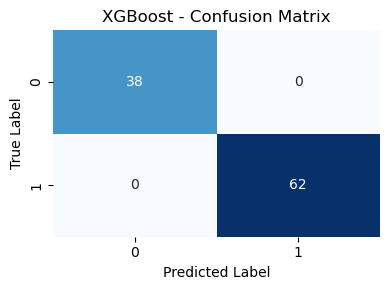


 Model: CatBoost
Accuracy: 1.0000
Confusion Matrix:
[[38  0]
 [ 0 62]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        62

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



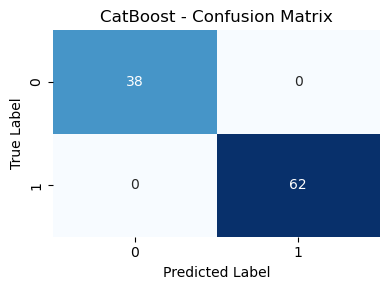

In [36]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


X = df.drop(columns=['class'])
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# models = {
#     'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
#     'CatBoost': CatBoostClassifier(verbose=0)
# }
models = {
    'XGBoost': XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=150 / 250,  
        random_state=42
    ),
    'CatBoost': CatBoostClassifier(
        verbose=0,
        class_weights=[1.0, 150 / 250], 
        random_state=42
    )
}

for name, model in models.items():
    print(f"\n Model: {name}\n{'='*40}")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")


    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)


    print("Classification Report:")
    print(classification_report(y_test, y_pred))


    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
